# Freight Rate Prediction using XGBoost

## ML Engineer Assessment


## Candidate: Pankaj Patil

### Objective
Build a machine learning model to predict freight rates (`posted_rate`) using historical shipment data and generate predictions for the validation and December datasets.

### Workflow
1. Import Libraries
2. Load Datasets
3. Exploratory Data Analysis (EDA)
4. Data Cleaning
5. Feature Engineering
6. Categorical Encoding
7. Train-Test Split
8. Model Training (XGBoost)
9. Model Evaluation
10. Validation Prediction
11. December Prediction
12. Score Validation

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import OrdinalEncoder

from xgboost import XGBRegressor

## 2. Load Datasets

In [2]:
train = pd.read_csv("train-test.csv")
validation = pd.read_csv("validation.csv")
december = pd.read_csv("december-chart-inputs.csv")

In [3]:
print("Train Shape      :", train.shape)
print("Validation Shape :", validation.shape)
print("December Shape   :", december.shape)

Train Shape      : (48000, 14)
Validation Shape : (12000, 13)
December Shape   : (31, 7)


In [4]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2. Exploratory Data Analysis (EDA)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 7.1 MB


In [6]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
load_id,48000,48000,TR-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup,48000,64,Oklahoma City,1242,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delivery,48000,64,Lexington,1197,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pickup_lat,48000.0,NaN,NaN,NaN,35.647545,4.315285,28.35765,31.98691,35.29479,39.41104,44.30296
pickup_lon,48000.0,NaN,NaN,NaN,-90.928964,13.482431,-121.69849,-98.40059,-88.08915,-83.28506,-69.5
delivery_lat,48000.0,NaN,NaN,NaN,35.641175,4.317199,28.35765,31.98691,35.29479,39.41104,44.30296
delivery_lon,48000.0,NaN,NaN,NaN,-90.85731,13.476589,-121.69849,-98.40059,-87.52871,-83.28506,-69.5
distance,48000.0,NaN,NaN,NaN,1135.856654,728.564416,70.0,550.4,953.3,1645.525,3439.8
equipment,48000,3,Dry Van,27202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,47700.0,NaN,NaN,NaN,31028.844004,9391.44062,-47500.0,25800.0,31436.5,37018.0,47500.0


In [7]:
missing = train.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

print(missing)

market_index    374
weight          300
dtype: int64


In [11]:
print(train.isnull().sum().sort_values(ascending=False))

market_index    374
weight          300
delivery          0
pickup_lat        0
load_id           0
pickup            0
delivery_lat      0
pickup_lon        0
distance          0
delivery_lon      0
equipment         0
date              0
quote_signal      0
posted_rate       0
dtype: int64


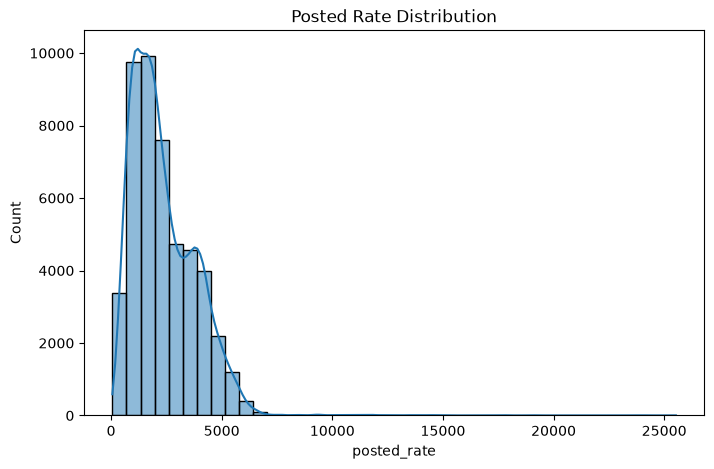

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(train["posted_rate"], bins=40, kde=True)

plt.title("Posted Rate Distribution")

plt.show()

In [12]:
train.loc[train["weight"] < 0, "weight"] = np.nan

In [13]:
train["weight"] = train["weight"].fillna(train["weight"].median())

train["market_index"] = train["market_index"].fillna(
    train["market_index"].median()
)

In [14]:
train.isnull().sum()

load_id         0
pickup          0
delivery        0
pickup_lat      0
pickup_lon      0
delivery_lat    0
delivery_lon    0
distance        0
equipment       0
weight          0
date            0
market_index    0
quote_signal    0
posted_rate     0
dtype: int64

## 4. Feature Engineering

In [15]:
# Convert date column
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

# Create date features
for df in [train, validation]:

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

In [16]:
train["route"] = train["pickup"] + "_" + train["delivery"]

validation["route"] = validation["pickup"] + "_" + validation["delivery"]

In [17]:
train.drop(columns=["date"], inplace=True)

validation.drop(columns=["date"], inplace=True)

## 5. Encode Categorical Features

In [18]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

train[cat_cols] = encoder.fit_transform(train[cat_cols])

validation[cat_cols] = encoder.transform(validation[cat_cols])

In [19]:
features = [
    "pickup",
    "delivery",
    "distance",
    "equipment",
    "weight",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear"
]

target = "posted_rate"

In [20]:
X = train[features]

y = train[target]

X_validation = validation[features]

## 6. Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (38400, 10)
Testing Shape  : (9600, 10)


## 7. Model Training (XGBoost)

In [22]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [23]:
y_pred = xgb.predict(X_test)

## 8. Model Evaluation

In [24]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("RMSE :", rmse)
print("R2   :", r2)

MAE  : 153.55495910631817
RMSE : 557.8227293847655
R2   : 0.8545023138187642


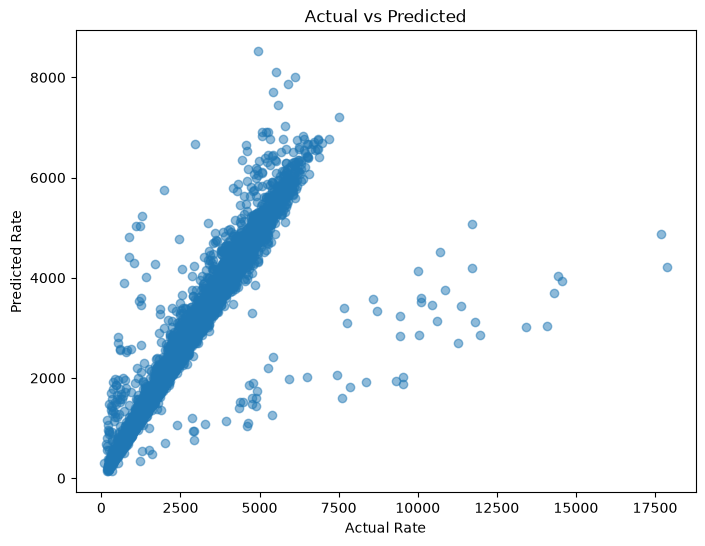

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Rate")

plt.ylabel("Predicted Rate")

plt.title("Actual vs Predicted")

plt.show()

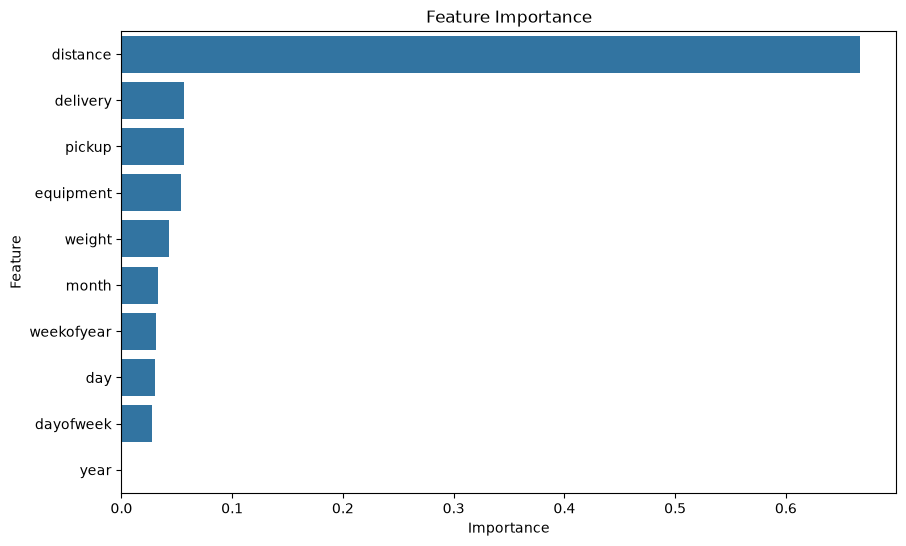

,Feature,Importance
2,distance,0.666494
1,delivery,0.056704
0,pickup,0.056356
3,equipment,0.054175
4,weight,0.043277
6,month,0.032838
9,weekofyear,0.031504
7,day,0.030739
8,dayofweek,0.027913
5,year,0.000000


In [26]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

importance

## 9. Validation Prediction

In [27]:
validation_prediction = xgb.predict(X_validation)

In [28]:
submission = pd.DataFrame({
    "load_id": validation["load_id"],
    "predicted_rate": validation_prediction
})

submission.to_csv("validation_predictions.csv", index=False)

submission.head()

,load_id,predicted_rate
0,TE-000001,1060.594482
1,TE-000002,4788.091797
2,TE-000003,5230.041016
3,TE-000004,4629.129395
4,TE-000005,1727.093384


## 10. December Prediction

In [29]:
december = pd.read_csv("december-chart-inputs.csv")

# Keep original dataframe safe
december_original = december.copy()

# Copy for preprocessing
dec_input = december.copy()

In [30]:
dec_input["date"] = pd.to_datetime(dec_input["date"])

dec_input["year"] = dec_input["date"].dt.year
dec_input["month"] = dec_input["date"].dt.month
dec_input["day"] = dec_input["date"].dt.day
dec_input["dayofweek"] = dec_input["date"].dt.dayofweek
dec_input["weekofyear"] = dec_input["date"].dt.isocalendar().week.astype(int)

In [31]:
dec_input["route"] = (
    dec_input["pickup"] + "_" + dec_input["delivery"]
)

In [32]:
cat_cols = [
    "pickup",
    "delivery",
    "equipment",
    "route"
]

dec_input[cat_cols] = encoder.transform(
    dec_input[cat_cols]
)

In [33]:
X_december = dec_input[features]

## 11. Score Validation

In [37]:
dec_prediction = xgb.predict(X_december)

In [38]:
december_original["predicted_rate"] = dec_prediction

december_original.to_csv(
    "december_predictions.csv",
    index=False
)

december_original.head()

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,1022.863647
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,989.976257
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,1023.370972
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,1032.288208
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,1041.313965


In [39]:
import sys

!{sys.executable} score.py \
--predictions validation_predictions.csv \
--december-predictions december_predictions.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.
